# Notebook 01: Descriptive Statistics

Full distributional characterisation of RA values across all 23 conditions and 3 models.

**Requires**: `analysis/data/exp1_df.parquet` from nb_00.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

df_exp1 = pd.read_parquet(DATA_DIR / "exp1_df.parquet")
df_exp0 = pd.read_parquet(DATA_DIR / "exp0_df.parquet")

MODELS = ["early_fusion", "c2former", "ua_cmddet"]
MODEL_LABELS = {"early_fusion": "Early Fusion", "c2former": "C2Former", "ua_cmddet": "UA-CMDet"}
COLORS = {"early_fusion": "#1f77b4", "c2former": "#2ca02c", "ua_cmddet": "#d62728"}

print(f"exp1: {df_exp1.shape[0]} rows x {df_exp1.shape[1]} columns")
print(df_exp1.dtypes)

exp1: 69 rows x 7 columns
model             str
modality          str
corruption        str
severity          str
map           float64
clean_map     float64
ra            float64
dtype: object


## 1. Summary Statistics — RA per Model

All 23 corruption conditions (21 graded + 2 complete dropouts).

In [2]:
summary = (
    df_exp1.groupby("model")["ra"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        min_ra="min",
        max_ra="max",
    )
    .rename(index=MODEL_LABELS)
)
summary["IQR"] = summary["q75"] - summary["q25"]
summary["CV"] = summary["std"] / summary["mean"]  # coefficient of variation

print("=== RA Summary Statistics (all 23 conditions) ===")
print(summary[["n", "mean", "std", "median", "IQR", "min_ra", "max_ra", "CV"]].to_string())

=== RA Summary Statistics (all 23 conditions) ===
               n   mean    std  median    IQR  min_ra  max_ra     CV
model                                                               
C2Former      23 0.8701 0.1138  0.8932 0.1228  0.5500  0.9951 0.1308
Early Fusion  23 0.8119 0.1781  0.8704 0.2026  0.3090  0.9943 0.2193
UA-CMDet      23 0.7477 0.3069  0.8438 0.2921  0.0058  1.0150 0.4105


## 2. RGB vs TIR Robustness — Mean RA by Modality Stream

In [3]:
# Graded conditions only (exclude complete_dropout for clean comparison)
graded = df_exp1[df_exp1["severity"] != "sdropout"].copy()

modality_summary = (
    graded.groupby(["model", "modality"])["ra"]
    .agg(mean="mean", std="std", min_ra="min", max_ra="max")
    .reset_index()
)
modality_summary["model_label"] = modality_summary["model"].map(MODEL_LABELS)

print("=== Mean RA by model and modality stream (graded conditions only) ===")
pivot = modality_summary.pivot_table(index="model_label", columns="modality", values=["mean", "std"])
print(pivot.to_string())

=== Mean RA by model and modality stream (graded conditions only) ===
               mean           std       
modality        rgb    tir    rgb    tir
model_label                             
C2Former     0.8852 0.9139 0.0683 0.0764
Early Fusion 0.7936 0.9142 0.1573 0.0662
UA-CMDet     0.6268 0.9625 0.2757 0.0597


In [4]:
# Complete dropout (worst-case modality failure)
dropouts = df_exp1[df_exp1["corruption"] == "complete_dropout"].copy()
dropouts["model_label"] = dropouts["model"].map(MODEL_LABELS)

print("=== Complete Dropout RA (binary, worst-case) ===")
print(dropouts[["model_label", "modality", "ra"]].pivot(index="model_label", columns="modality", values="ra").to_string())

=== Complete Dropout RA (binary, worst-case) ===
modality        rgb    tir
model_label               
C2Former     0.5500 0.6158
Early Fusion 0.6141 0.3090
UA-CMDet     0.0058 1.0072


## 3. RA Heatmap — All Conditions × All Models

Rows = 23 corruption conditions, columns = 3 models. Diverging colormap centred at 1.0 (no degradation).

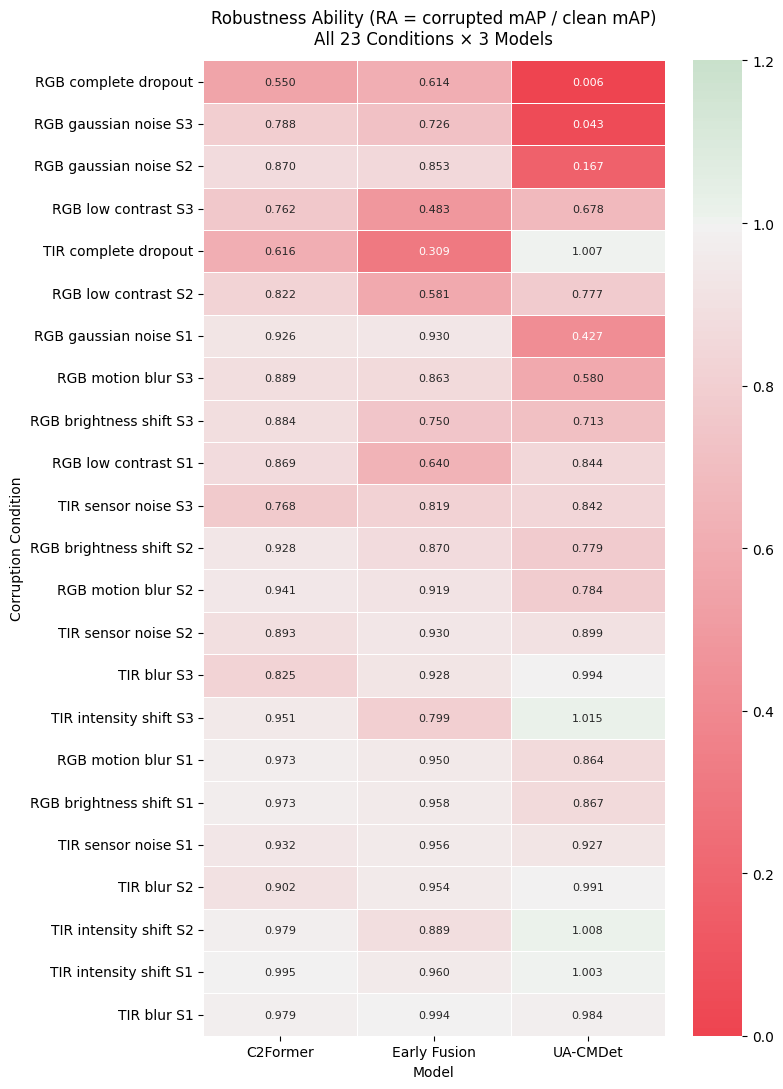

Saved: nb01_ra_heatmap.png


In [5]:
# Build a condition label combining modality + corruption + severity
def condition_label(row):
    mod = row["modality"].upper()
    corr = row["corruption"].replace("_", " ")
    sev = row["severity"]
    if sev == "sdropout":
        return f"{mod} {corr}"
    return f"{mod} {corr} S{sev}"

df_exp1["condition"] = df_exp1.apply(condition_label, axis=1)

# Pivot to (condition x model)
heatmap_data = df_exp1.pivot_table(index="condition", columns="model", values="ra", aggfunc="first")
heatmap_data = heatmap_data.rename(columns=MODEL_LABELS)

# Sort rows by mean RA ascending (worst conditions first)
heatmap_data["_mean"] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values("_mean").drop(columns="_mean")

fig, ax = plt.subplots(figsize=(8, 11))
cmap = sns.diverging_palette(10, 130, s=80, l=55, n=256, as_cmap=True)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    center=1.0,
    vmin=0.0,
    vmax=1.2,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Robustness Ability (RA = corrupted mAP / clean mAP)\nAll 23 Conditions × 3 Models", fontsize=12, pad=12)
ax.set_xlabel("Model", fontsize=10)
ax.set_ylabel("Corruption Condition", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb01_ra_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb01_ra_heatmap.png")

## 4. RA Distribution — Violin + Strip Plots

Shows the spread of RA values across the 23 conditions for each model.

C:\Users\saksh\AppData\Local\Temp\ipykernel_26868\1597098911.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\saksh\AppData\Local\Temp\ipykernel_26868\1597098911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


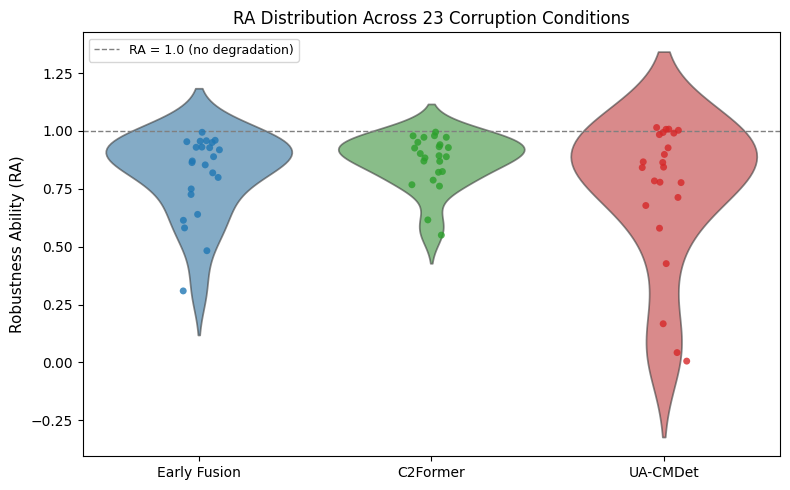

Saved: nb01_ra_violin.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = df_exp1.copy()
plot_df["Model"] = plot_df["model"].map(MODEL_LABELS)

sns.violinplot(
    data=plot_df,
    x="Model",
    y="ra",
    order=[MODEL_LABELS[m] for m in MODELS],
    palette=[COLORS[m] for m in MODELS],
    inner=None,
    alpha=0.6,
    ax=ax,
)
sns.stripplot(
    data=plot_df,
    x="Model",
    y="ra",
    order=[MODEL_LABELS[m] for m in MODELS],
    palette=[COLORS[m] for m in MODELS],
    size=5,
    jitter=True,
    alpha=0.8,
    ax=ax,
)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="RA = 1.0 (no degradation)")
ax.set_ylabel("Robustness Ability (RA)", fontsize=11)
ax.set_xlabel("")
ax.set_title("RA Distribution Across 23 Corruption Conditions", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb01_ra_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb01_ra_violin.png")

## 5. Ranked RA Table — All 69 Values Ascending

Full ranked list from worst to best across the entire study.

In [7]:
ranked = (
    df_exp1[["model", "modality", "corruption", "severity", "map", "ra"]]
    .sort_values("ra")
    .reset_index(drop=True)
)
ranked.index += 1  # 1-indexed rank
ranked["model"] = ranked["model"].map(MODEL_LABELS)

print("=== All 69 RA values ranked worst → best ===")
print(ranked.to_string())

=== All 69 RA values ranked worst → best ===
           model modality        corruption  severity    map     ra
1       UA-CMDet      rgb  complete_dropout  sdropout 0.0012 0.0058
2       UA-CMDet      rgb    gaussian_noise         3 0.0091 0.0426
3       UA-CMDet      rgb    gaussian_noise         2 0.0357 0.1672
4   Early Fusion      tir  complete_dropout  sdropout 0.1498 0.3090
5       UA-CMDet      rgb    gaussian_noise         1 0.0912 0.4270
6   Early Fusion      rgb      low_contrast         3 0.2340 0.4827
7       C2Former      rgb  complete_dropout  sdropout 0.3875 0.5500
8       UA-CMDet      rgb       motion_blur         3 0.1239 0.5799
9   Early Fusion      rgb      low_contrast         2 0.2818 0.5812
10  Early Fusion      rgb  complete_dropout  sdropout 0.2977 0.6141
11      C2Former      tir  complete_dropout  sdropout 0.4339 0.6158
12  Early Fusion      rgb      low_contrast         1 0.3102 0.6397
13      UA-CMDet      rgb      low_contrast         3 0.1449 0.6780
14 

## 6. Per-Class Baseline AP (exp0)

Available for Early Fusion and C2Former. UA-CMDet per-class is not available from COCOeval.

In [8]:
ap_cols = [c for c in df_exp0.columns if c.startswith("ap_")]
if ap_cols:
    perclass = df_exp0[["model"] + ap_cols + ["map"]].copy()
    perclass["model"] = perclass["model"].map(MODEL_LABELS)
    perclass.columns = [c.replace("ap_", "") for c in perclass.columns]
    print("=== Per-class AP at clean baseline ===")
    print(perclass.set_index("model").to_string())
else:
    print("No per-class AP columns found in exp0.")

=== Per-class AP at clean baseline ===
                car  truck  freight_car    bus    van    map
model                                                       
C2Former     0.8940 0.6820       0.5420 0.8890 0.5150 0.7046
Early Fusion    NaN    NaN          NaN    NaN    NaN 0.4848
UA-CMDet        NaN    NaN          NaN    NaN    NaN 0.2137


In [9]:
from io import StringIO
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
buf = StringIO()

buf.write("=== NB01 DESCRIPTIVE STATISTICS ===\n\n")

buf.write("--- Summary stats (all 23 conditions) ---\n")
buf.write(summary[["n", "mean", "std", "median", "IQR", "min_ra", "max_ra", "CV"]].round(4).to_string() + "\n\n")

buf.write("--- Mean RA by modality stream (graded only) ---\n")
buf.write(pivot.round(4).to_string() + "\n\n")

buf.write("--- Complete dropout RA ---\n")
buf.write(dropouts[["model_label", "modality", "ra"]].pivot(index="model_label", columns="modality", values="ra").round(4).to_string() + "\n\n")

buf.write("--- Top 15 worst RA conditions ---\n")
buf.write(ranked.head(15).to_string() + "\n\n")

buf.write("--- Per-class baseline AP ---\n")
if ap_cols:
    buf.write(perclass.set_index("model").round(4).to_string() + "\n")
else:
    buf.write("Not available\n")

out_path = OUTPUT_DIR / "nb01_results.txt"
out_path.write_text(buf.getvalue())
print(f"Results written to {out_path.resolve()}")

Results written to C:\Users\saksh\Desktop\Thesis\drone-multimodal-robustness\analysis\outputs\nb01_results.txt


## Summary

Key numbers to carry into thesis methodology section:

- Mean RA and IQR per model (table from section 1)
- RGB vs TIR mean RA split (section 2)
- Worst-case (RA_min) and best-case (RA_max) per model (section 1)

Proceed to `nb_02_severity_analysis.ipynb`.